🎯 SUBJECT EXTRACTION - BLACK BACKGROUND ONLY (COLAB VERSION)
Using device: cuda
✅ Custom model loaded successfully!
📤 Please upload your images (multiple selection allowed):


Saving apple_158989157.jpg to apple_158989157 (10).jpg
Saving download (1).jfif to download (1) (3).jfif
Saving download (3).jfif to download (3) (11).jfif
Saving download.jfif to download (14).jfif
Saving images (1).jfif to images (1) (4).jfif
Saving images.jfif to images (11).jfif

🔄 Processing 6 uploaded images...

[1/6] Processing: apple_158989157 (10).jpg
💾 Saved: apple_158989157 (10)_black_bg.jpg


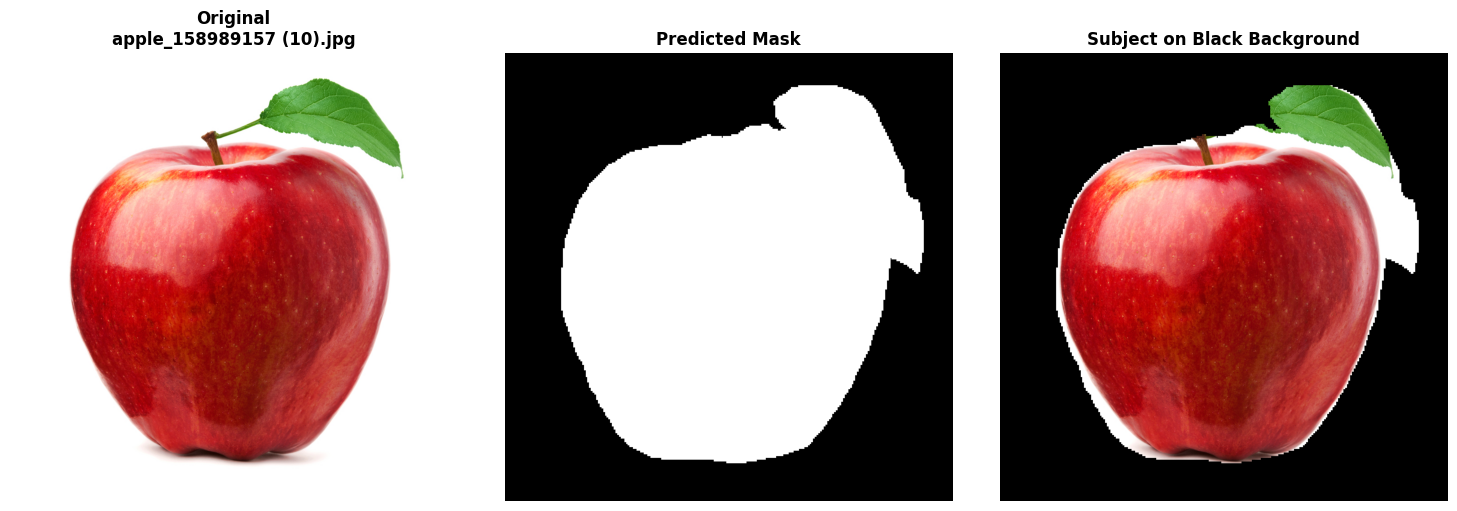


[2/6] Processing: download (1) (3).jfif
💾 Saved: download (1) (3)_black_bg.jpg


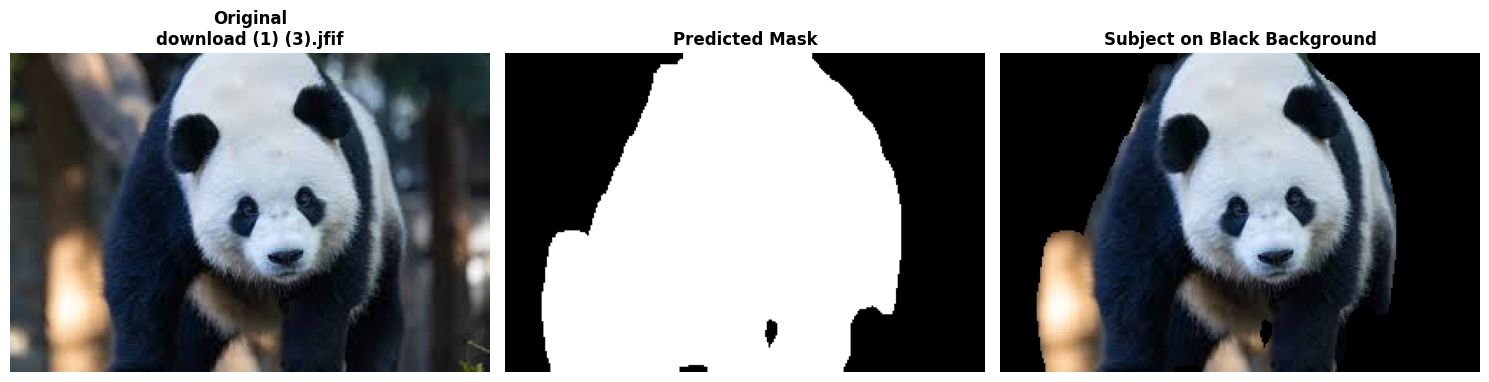


[3/6] Processing: download (3) (11).jfif
💾 Saved: download (3) (11)_black_bg.jpg


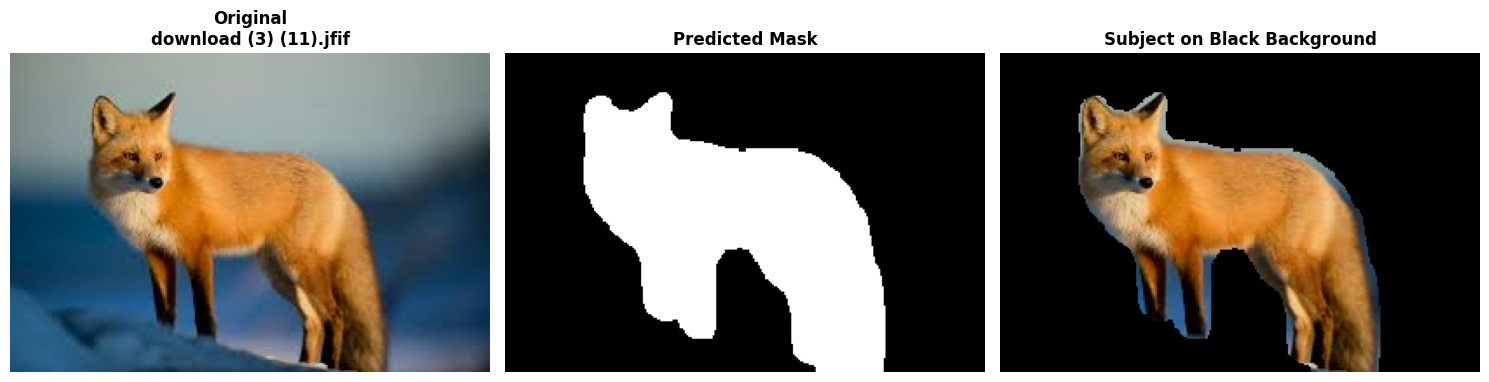


[4/6] Processing: download (14).jfif
💾 Saved: download (14)_black_bg.jpg


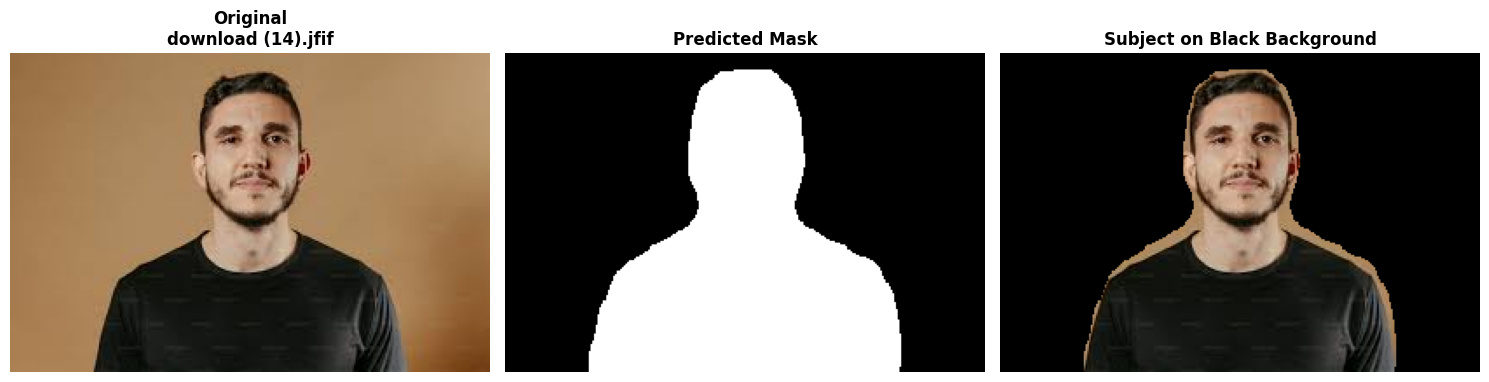


[5/6] Processing: images (1) (4).jfif
💾 Saved: images (1) (4)_black_bg.jpg


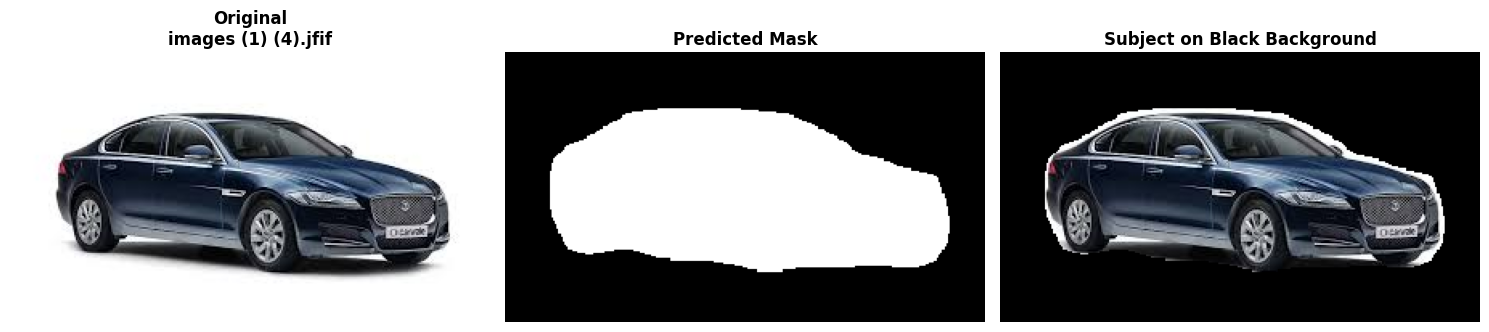


[6/6] Processing: images (11).jfif
💾 Saved: images (11)_black_bg.jpg


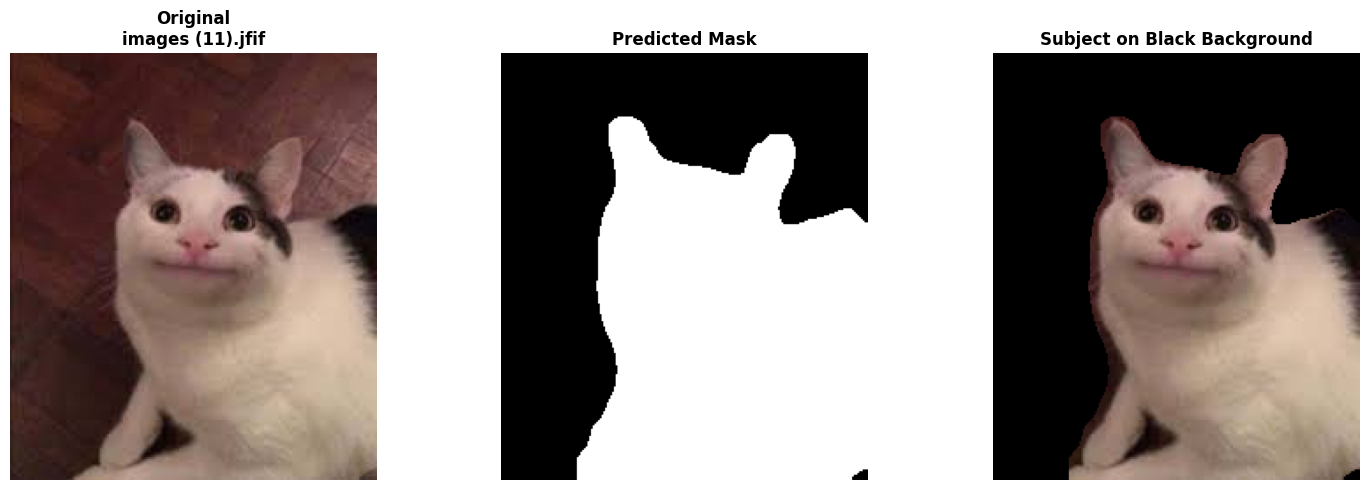


🎉 Completed processing 6 images!
📁 All results saved to: black_bg_results/

📦 Creating download package...
📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn
from google.colab import files
from PIL import Image
import io

print("🎯 SUBJECT EXTRACTION - BLACK BACKGROUND ONLY (COLAB VERSION)")
print("=" * 60)

# ================= Device =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= Model Loading =================
num_classes = 2
model_path = "deeplabv3_segmentation.pth"  # Your trained model

try:
    # Try loading your custom model first
    model = deeplabv3_resnet50(pretrained=False, aux_loss=True)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Custom model loaded successfully!")
except:
    # Fallback to pre-trained with modified classifier
    print("❌ Custom model not found, using pre-trained model...")
    model = deeplabv3_resnet50(pretrained=True)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

model.to(device)
model.eval()

# ================= Preprocess =================
def preprocess_image(img, long_side=256):
    """Preprocess image for model inference"""
    h, w = img.shape[:2]
    scale = long_side / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h))

    # Convert to tensor and normalize
    img_tensor = torch.tensor(img_resized / 255., dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    img_tensor = (img_tensor - mean) / std

    return img_tensor.to(device), (h, w)

# ================= Prediction =================
def predict_mask(img_tensor):
    """Get mask prediction from model"""
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, dict):
            output = output['out']
        return output

# ================= Post-process mask =================
def postprocess_mask(mask_tensor, orig_size):
    """Clean and resize mask to original size"""
    mask = torch.argmax(mask_tensor, dim=1).squeeze().cpu().numpy()
    mask = cv2.resize(mask.astype(np.uint8), (orig_size[1], orig_size[0]),
                     interpolation=cv2.INTER_NEAREST)

    # Morphological operations to clean mask
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)

    return mask

# ================= Extract Object on Black Background =================
def extract_object_black_bg(img, mask):
    """Extract object on black background"""
    result = np.zeros_like(img)
    result[mask == 1] = img[mask == 1]
    return result

# ================= Process Uploaded Images =================
def process_uploaded_images():
    """Process images uploaded to Colab"""
    print("📤 Please upload your images (multiple selection allowed):")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No images uploaded!")
        return

    # Create output directory
    output_dir = "black_bg_results"
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n🔄 Processing {len(uploaded)} uploaded images...")

    for i, (filename, file_data) in enumerate(uploaded.items()):
        print(f"\n[{i+1}/{len(uploaded)}] Processing: {filename}")

        try:
            # Read image from uploaded data
            image = Image.open(io.BytesIO(file_data))
            img_rgb = np.array(image)

            # Preprocess and predict
            img_tensor, orig_size = preprocess_image(img_rgb)
            mask_tensor = predict_mask(img_tensor)
            pred_mask = postprocess_mask(mask_tensor, orig_size)

            # Extract object on black background
            black_bg_result = extract_object_black_bg(img_rgb, pred_mask)

            # Save results
            base_name = os.path.splitext(filename)[0]

            # Save original image
            cv2.imwrite(os.path.join(output_dir, f"{base_name}_original.jpg"),
                        cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

            # Save mask
            cv2.imwrite(os.path.join(output_dir, f"{base_name}_mask.png"), pred_mask * 255)

            # Save black background result
            cv2.imwrite(os.path.join(output_dir, f"{base_name}_black_bg.jpg"),
                        cv2.cvtColor(black_bg_result, cv2.COLOR_RGB2BGR))

            print(f"💾 Saved: {base_name}_black_bg.jpg")

            # Visualize results
            visualize_results(img_rgb, pred_mask, black_bg_result, filename)

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")
            continue

    print(f"\n🎉 Completed processing {len(uploaded)} images!")
    print(f"📁 All results saved to: {output_dir}/")

    # Create zip file for download
    print("\n📦 Creating download package...")
    os.system(f"zip -r black_bg_results.zip {output_dir}/")

    print("📥 Downloading results...")
    files.download("black_bg_results.zip")

# ================= Visualize Results =================
def visualize_results(original_img, mask, black_bg_result, filename):
    """Display processing results"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title(f"Original\n{filename}", fontweight='bold', fontsize=12)
    axes[0].axis('off')

    # Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Predicted Mask", fontweight='bold', fontsize=12)
    axes[1].axis('off')

    # Black background result
    axes[2].imshow(black_bg_result)
    axes[2].set_title("Subject on Black Background", fontweight='bold', fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# ================= MAIN EXECUTION =================
if __name__ == "__main__":
    # Run the Colab version
    process_uploaded_images()